In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs_pure
import loglike_pure
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = (12+3)/12     # Total time



print(f"Using dt = {dt} seconds, T = {T} years")



print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs_pure.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


Using dt = 10 seconds, T = 1.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 17.04395985627843
Setting up log_density and prior functions...


In [ ]:

def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
        print(loglike)

    return log_likes

In [3]:
best_fit = [6.00074373, 1.00021502, 0.70162414, 8.9906778 , 0.39978561]
log_density(np.array(best_fit).reshape(1,-1))

16.300244157205146


array([16.30024416])

In [4]:
log_density([param_true])

16.8623645216297


array([16.86236452])

In [5]:
from scipy.optimize import minimize

def neg_logden(x):
    val = log_density(np.array([x]))[0]
    return -val if np.isfinite(val) else 1e10

result = minimize(neg_logden, x0=best_fit, method='Nelder-Mead',
                  options={'xatol':1e-6, 'fatol':1e-6, 'maxiter':10000, 
                           'adaptive':True, 'disp':True})

best_fit_new = result.x
print('peak:', best_fit_new)
print('logden:', -result.fun)

16.300244157205146
0.009804202061159275
0.0015880488538783499
0.006491601290754068
-5.1190789936279043e-05
-4.971707924809581e-05
0.00020168054901861218
-0.001242464508346192
5.449455536752507e-06
0.00010092130617820893
0.0003317009666147607
0.006820961940805683
0.0006278326356535334
-0.001351128357025716
0.039755319245847756
-0.0047967026934903805
-0.0015757408547041846
0.0020076659407220984
-0.00024812814579127946
-0.00532547007138101
0.000435339445530019
-0.007765582612984154
1.5989005583497134e-05
0.0003469485488289917
0.005890004731031416
0.002131850021887547
0.007698675547857509
0.001207931012455037
2.7902739842965037e-05
0.0030525411168192814
-0.001985963059506564
-0.0006466072338973422
-0.0013187528881103993
0.002423594377679208
-0.0016871615582565113
-0.0044288364770793485
-0.006974549392331604
0.002766793571561162
-0.005089055818705216
0.0005130820956096242
0.0023863405181064087
0.0007657393200048422
0.0010968612372617883
0.00044090484303569344
0.0004474594279601351
0.0031487

In [6]:
best_fit, result.x

([6.00074373, 1.00021502, 0.70162414, 8.9906778, 0.39978561],
 array([6.00074478, 1.00020844, 0.70161788, 8.99064945, 0.39978685]))

# connection

In [10]:
proc1_maxld_pt = result.x.copy().reshape(1,-1)
proc1_maxld_pt

array([[6.00074478, 1.00020844, 0.70161788, 8.99064945, 0.39978685]])

In [11]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [12]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


16.64660081502488
16.656390875776072
16.665115925027564
16.67289075287225
16.679821150479288
16.686012514717817
16.69155416356459
16.696535567892525
16.701038318938515
16.705140670697574
16.708911354100014
16.71241919290774
16.71572430435782
16.718887009657557
16.721964479240192
16.724994324805206
16.728032060234213
16.731107689846652
16.734265935851614
16.73753176268128
16.740933659352528
16.744495656612663
16.748232231898523
16.752158221205775
16.75628064767195
16.76060400522823
16.765126893830608
16.769845366595174
16.77474269554725
16.77981893420742
16.785039854962026
16.790394222381746
16.795849371336978
16.801378396880175
16.806948853294443
16.812518534287758
16.818050656200093
16.82349847749721
16.82881885878733
16.833955906164274
16.83886249264455
16.843479230404743
16.84775139754581
16.851612897037246
16.855002491130268
16.85785267620369
16.860090709573434
16.861642559523677
16.862428633764573
16.8623645216297


In [13]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


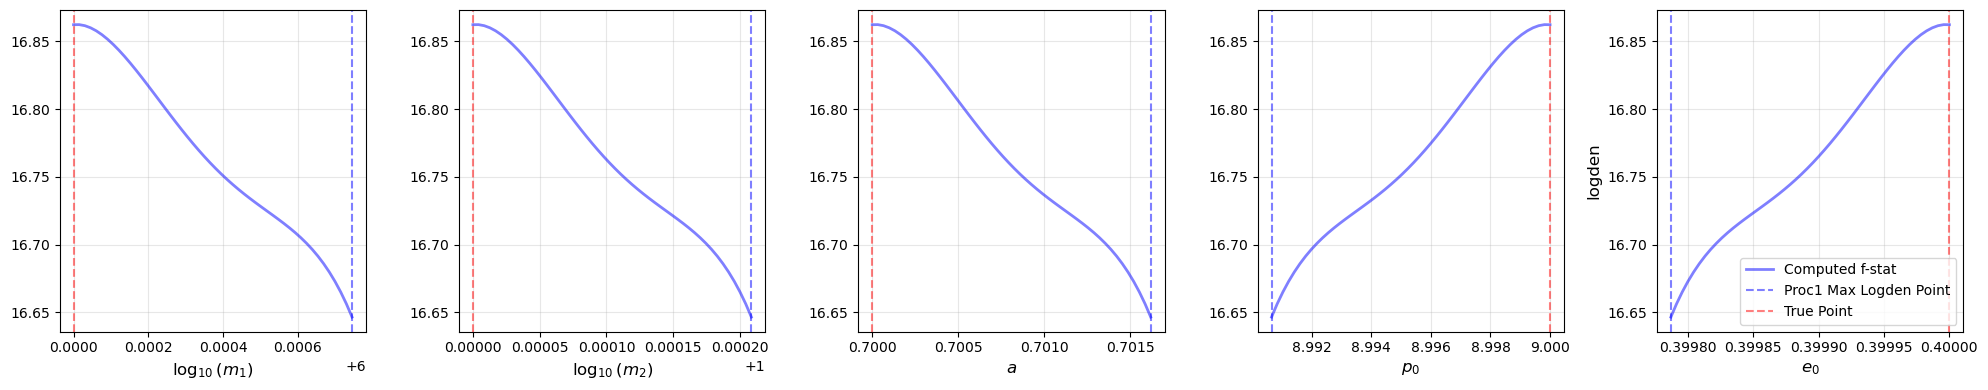

In [14]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
